# GLiClass — Full Benchmark Evaluation (Same Data as GliZNet)

Evaluates **GLiClass** models on the **exact same datasets and loading logic** used in the GliZNet benchmark notebook, so we get an apples-to-apples comparison of macro F1.

**Models evaluated**:
- `knowledgator/gliclass-base-v3.0`
- `knowledgator/gliclass-large-v3.0`
- `knowledgator/gliclass-modern-base-v3.0`

**Datasets** (10 — same as FullGliznetEval):
CR, SST-2, SST-5, IMDb, 20-Newsgroups, Enron Spam, Financial PhraseBank, AG News, Emotion, Rotten Tomatoes

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, ClassLabel
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

DEVICE     = "cuda:0" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16

print(f"Device : {DEVICE}")

Device : cuda:0


## Load GLiClass models

In [2]:
from gliclass import GLiClassModel, ZeroShotClassificationPipeline
from gliclass.model import GLiClassModelConfig
from transformers import AutoTokenizer
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download

MODELS = [
    "knowledgator/gliclass-base-v3.0",
    "knowledgator/gliclass-large-v3.0",
    "knowledgator/gliclass-modern-base-v3.0",
]

def load_gliclass_pipeline(model_name, device=DEVICE):
    """Load a GLiClass pipeline with manual weight loading.
    transformers 5.x from_pretrained silently fails to apply checkpoint weights
    for unregistered model types, so we load them manually via load_state_dict."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    config = GLiClassModelConfig.from_pretrained(model_name)
    config.pad_token_id = tokenizer.pad_token_id

    _orig_tie_weights = GLiClassModel.tie_weights
    GLiClassModel.tie_weights = lambda self, **kwargs: _orig_tie_weights(self)

    # Create model with random weights, then load checkpoint manually
    model = GLiClassModel(config)
    ckpt_path = hf_hub_download(model_name, "model.safetensors")
    model.load_state_dict(load_file(ckpt_path), strict=True)

    pipe = ZeroShotClassificationPipeline(
        model, tokenizer,
        classification_type="multi-label",
        device=device, progress_bar=False
    )
    print(f"  ✓ {model_name}")
    return pipe

pipelines = {}
for name in MODELS:
    pipelines[name] = load_gliclass_pipeline(name)

# Sanity check
out = pipelines[MODELS[0]]("I absolutely loved this film!", ["positive", "negative", "neutral"], threshold=0.0)[0]
print("\nSanity check (base):")
for r in out:
    print(f"  {r['label']:<12} {r['score']:.3f}")

[transformers] You are using a model of type `GLiClass` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


  ✓ knowledgator/gliclass-base-v3.0


[transformers] You are using a model of type `GLiClass` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


  ✓ knowledgator/gliclass-large-v3.0


[transformers] You are using a model of type `GLiClass` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


  ✓ knowledgator/gliclass-modern-base-v3.0

Sanity check (base):
  positive     1.000
  negative     0.010
  neutral      0.118


## Dataset loading helpers (identical to GliZNet eval)

In [3]:
def get_test_split(ds):
    """Return the test (or fallback validation/train) split."""
    for key in ("test", "validation", "train"):
        if key in ds:
            return ds[key]
    raise ValueError("No usable split found")


def resolve_labels(split, label_col):
    """Return (class_names: list[str], int_to_str callable)."""
    feat = split.features.get(label_col)
    if isinstance(feat, ClassLabel):
        classes = feat.names
        to_str = lambda i: classes[i]
    else:
        raw_classes = sorted(set(split[label_col]))
        classes = [str(c) for c in raw_classes]
        to_str = lambda x: str(x)
    return classes, to_str


def prepare(ds, text_col="text", label_col="label", classes=None, to_str=None):
    """Return (texts, classes, true_labels)."""
    split = get_test_split(ds)
    if classes is None:
        classes, to_str = resolve_labels(split, label_col)
    raw = split[label_col]
    true_labels = [to_str(l) for l in raw]
    return list(split[text_col]), classes, true_labels

In [4]:
def predict_batch_gliclass(pipe, texts, classes, batch_size=BATCH_SIZE):
    """Return the top predicted class string for each text using GLiClass.
    Multi-label mode with threshold=0.0 returns all labels; we pick the argmax."""
    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="  inference", leave=False):
        batch_texts = texts[i : i + batch_size]
        for text in batch_texts:
            raw = pipe(text, classes, threshold=0.0)[0]
            score_map = {r["label"]: r["score"] for r in raw}
            best = max(classes, key=lambda c: score_map.get(c, 0.0))
            preds.append(best)
    return preds


def evaluate(preds, true_labels):
    return {
        "macro":    f1_score(true_labels, preds, average="macro"),
        "micro":    f1_score(true_labels, preds, average="micro"),
        "weighted": f1_score(true_labels, preds, average="weighted"),
    }

## Load all datasets (once, reuse across models)

In [5]:
DATASETS = [
    "SetFit/CR",
    "SetFit/sst2",
    "SetFit/sst5",
    "stanfordnlp/imdb",
    "SetFit/20_newsgroups",
    "SetFit/enron_spam",
    "mteb/financial_phrasebank",
    "ag_news",
    "dair-ai/emotion",
    "cornell-movie-review-data/rotten_tomatoes",
]

dataset_cache = {}

for dataset_id in DATASETS:
    print(f"Loading {dataset_id}...")
    try:
        if dataset_id == "stanfordnlp/imdb":
            classes = ["negative", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id)
            texts, _, true_labels = prepare(ds, label_col="label", classes=classes, to_str=_to)

        elif dataset_id == "SetFit/enron_spam":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id in ("SetFit/CR", "SetFit/sst2", "SetFit/sst5", "SetFit/20_newsgroups"):
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id == "mteb/financial_phrasebank":
            classes = ["negative", "neutral", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id, "sentences_allagree")
            texts, _, true_labels = prepare(ds, text_col="text", label_col="label", classes=classes, to_str=_to)

        else:
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds)

        dataset_cache[dataset_id] = (texts, classes, true_labels)
        print(f"  {len(texts)} samples, {len(classes)} classes → {classes[:5]}{'...' if len(classes) > 5 else ''}")

    except Exception as exc:
        import traceback; traceback.print_exc()
        dataset_cache[dataset_id] = None

print(f"\n✓ {sum(1 for v in dataset_cache.values() if v is not None)}/{len(DATASETS)} datasets loaded")

Loading SetFit/CR...


Repo card metadata block was not found. Setting CardData to empty.


  376 samples, 2 classes → ['negative', 'positive']
Loading SetFit/sst2...


Repo card metadata block was not found. Setting CardData to empty.


  1821 samples, 2 classes → ['negative', 'positive']
Loading SetFit/sst5...


...

  2210 samples, 5 classes → ['negative', 'neutral', 'positive', 'very negative', 'very positive']
Loading stanfordnlp/imdb...
  25000 samples, 2 classes → ['negative', 'positive']
Loading SetFit/20_newsgroups...


Repo card metadata block was not found. Setting CardData to empty.


  7532 samples, 20 classes → ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']...
Loading SetFit/enron_spam...


Repo card metadata block was not found. Setting CardData to empty.


  2000 samples, 2 classes → ['ham', 'spam']
Loading mteb/financial_phrasebank...
  1129 samples, 3 classes → ['negative', 'neutral', 'positive']
Loading ag_news...
  7600 samples, 4 classes → ['World', 'Sports', 'Business', 'Sci/Tech']
Loading dair-ai/emotion...
  2000 samples, 6 classes → ['sadness', 'joy', 'love', 'anger', 'fear']...
Loading cornell-movie-review-data/rotten_tomatoes...
  1066 samples, 2 classes → ['neg', 'pos']

✓ 10/10 datasets loaded


## Run evaluation on all models × all datasets

In [6]:
all_results = {}  # model_name → {dataset_id → scores_dict}

for model_name, pipe in pipelines.items():
    short = model_name.split("/")[-1]
    print(f"\n{'='*70}")
    print(f"  {short}")
    print(f"{'='*70}")

    model_results = {}
    for dataset_id in DATASETS:
        entry = dataset_cache.get(dataset_id)
        if entry is None:
            model_results[dataset_id] = {"macro": float("nan"), "micro": float("nan"), "weighted": float("nan")}
            continue

        texts, classes, true_labels = entry
        print(f"\n  {dataset_id}  ({len(texts)} samples, {len(classes)} classes)")

        try:
            preds  = predict_batch_gliclass(pipe, texts, classes)
            scores = evaluate(preds, true_labels)
            model_results[dataset_id] = scores
            print(f"    macro F1 = {scores['macro']:.4f}  |  micro = {scores['micro']:.4f}")
        except Exception as exc:
            import traceback; traceback.print_exc()
            model_results[dataset_id] = {"macro": float("nan"), "micro": float("nan"), "weighted": float("nan")}

    all_results[model_name] = model_results

print("\n\n✓ All models evaluated")


  gliclass-base-v3.0

  SetFit/CR  (376 samples, 2 classes)


  inference:   0%|          | 0/24 [00:00<?, ?it/s]

    macro F1 = 0.9127  |  micro = 0.9176

  SetFit/sst2  (1821 samples, 2 classes)


  inference:   0%|          | 0/114 [00:00<?, ?it/s]

    macro F1 = 0.8959  |  micro = 0.8962

  SetFit/sst5  (2210 samples, 5 classes)


...

    macro F1 = 0.7069  |  micro = 0.7234

  dair-ai/emotion  (2000 samples, 6 classes)


  inference:   0%|          | 0/125 [00:00<?, ?it/s]

    macro F1 = 0.4249  |  micro = 0.5185

  cornell-movie-review-data/rotten_tomatoes  (1066 samples, 2 classes)


  inference:   0%|          | 0/67 [00:00<?, ?it/s]

    macro F1 = 0.7060  |  micro = 0.7073


✓ All models evaluated


## Results table

In [7]:
rows = []
for ds_id in DATASETS:
    row = {"dataset": ds_id.split("/")[-1]}
    for model_name in MODELS:
        short = model_name.split("/")[-1]
        r = all_results.get(model_name, {}).get(ds_id, {})
        row[short] = round(r.get("macro", float("nan")), 4)
    rows.append(row)

df = pd.DataFrame(rows).set_index("dataset")

avg = df.mean(numeric_only=True)
avg.name = "AVERAGE"
df = pd.concat([df, avg.to_frame().T])

pd.set_option("display.float_format", "{:.4f}".format)
df

,gliclass-base-v3.0,gliclass-large-v3.0,gliclass-modern-base-v3.0
CR,0.9127,0.9281,0.8936
sst2,0.8959,0.9176,0.8982
sst5,0.3236,0.3798,0.2885
imdb,0.9248,0.9366,0.9154
20_newsgroups,0.5045,0.5806,0.3342
enron_spam,0.6252,0.7574,0.5903
financial_phrasebank,0.9094,0.9023,0.4121
ag_news,0.7209,0.7229,0.7069
emotion,0.4450,0.4504,0.4249
rotten_tomatoes,0.7943,0.8411,0.7060


## Bar chart

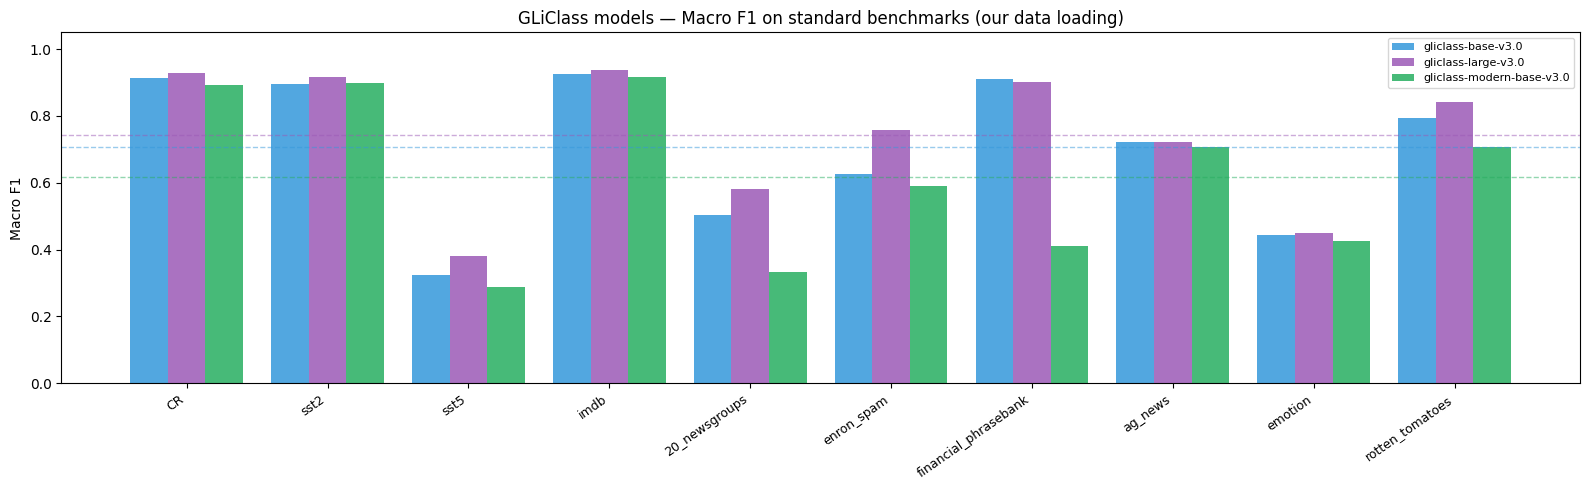


Averages:
  gliclass-base-v3.0                  avg macro F1 = 0.7056
  gliclass-large-v3.0                 avg macro F1 = 0.7417
  gliclass-modern-base-v3.0           avg macro F1 = 0.6170


In [8]:
plot_df = df.drop("AVERAGE").dropna()
x = np.arange(len(plot_df))
n_models = len(MODELS)
w = 0.8 / n_models

fig, ax = plt.subplots(figsize=(16, 5))
colors = ["#3498db", "#9b59b6", "#27ae60"]

for idx, model_name in enumerate(MODELS):
    short = model_name.split("/")[-1]
    offset = (idx - (n_models - 1) / 2) * w
    ax.bar(x + offset, plot_df[short], w, label=short, color=colors[idx], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
ax.set_title("GLiClass models — Macro F1 on standard benchmarks (our data loading)")
ax.legend(loc="upper right", fontsize=8)

for idx, model_name in enumerate(MODELS):
    short = model_name.split("/")[-1]
    avg_val = df.loc["AVERAGE", short]
    ax.axhline(avg_val, color=colors[idx], ls="--", lw=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("\nAverages:")
for idx, model_name in enumerate(MODELS):
    short = model_name.split("/")[-1]
    print(f"  {short:<35} avg macro F1 = {df.loc['AVERAGE', short]:.4f}")

## Export results dict (for use in GliZNet comparison notebook)

In [9]:
print("# Paste into FullGliznetEval.ipynb to replace published numbers\n")
for model_name in MODELS:
    short = model_name.split("/")[-1].upper().replace("-", "_").replace(".", "")
    print(f"{short} = {{")
    for ds_id in DATASETS:
        r = all_results.get(model_name, {}).get(ds_id, {})
        val = r.get("macro", float("nan"))
        print(f'    "{ds_id}":{" " * (45 - len(ds_id))}{val:.4f},')
    print("}\n")

# Paste into FullGliznetEval.ipynb to replace published numbers

GLICLASS_BASE_V30 = {
    "SetFit/CR":                                    0.9127,
    "SetFit/sst2":                                  0.8959,
    "SetFit/sst5":                                  0.3236,
    "stanfordnlp/imdb":                             0.9248,
    "SetFit/20_newsgroups":                         0.5045,
    "SetFit/enron_spam":                            0.6252,
    "mteb/financial_phrasebank":                    0.9094,
    "ag_news":                                      0.7209,
    "dair-ai/emotion":                              0.4450,
    "cornell-movie-review-data/rotten_tomatoes":    0.7943,
}

GLICLASS_LARGE_V30 = {
    "SetFit/CR":                                    0.9281,
    "SetFit/sst2":                                  0.9176,
    "SetFit/sst5":                                  0.3798,
    "stanfordnlp/imdb":                             0.9366,
    "SetFit/20_newsgroups":                    